In [3]:
import torch 
from torchvision import datasets, transforms

In [4]:
transform = transforms.Compose([transforms.ToTensor()]) 

In [6]:
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform) 

Using device: cuda
Training samples: 48000
Validation samples: 12000
Test samples: 10000
=== Training Basic CNN Model ===
Epoch [1/15], Train Loss: 0.6799, Val Loss: 0.4341, Val Acc: 84.70%
Epoch [2/15], Train Loss: 0.4275, Val Loss: 0.3493, Val Acc: 87.38%
Epoch [3/15], Train Loss: 0.3694, Val Loss: 0.3273, Val Acc: 87.49%
Epoch [4/15], Train Loss: 0.3385, Val Loss: 0.3187, Val Acc: 87.97%
Epoch [5/15], Train Loss: 0.3128, Val Loss: 0.2869, Val Acc: 89.68%
Epoch [6/15], Train Loss: 0.2710, Val Loss: 0.2540, Val Acc: 90.91%
Epoch [7/15], Train Loss: 0.2582, Val Loss: 0.2552, Val Acc: 90.69%
Epoch [8/15], Train Loss: 0.2495, Val Loss: 0.2437, Val Acc: 91.31%
Epoch [9/15], Train Loss: 0.2434, Val Loss: 0.2437, Val Acc: 91.20%
Epoch [10/15], Train Loss: 0.2352, Val Loss: 0.2374, Val Acc: 91.50%
Epoch [11/15], Train Loss: 0.2176, Val Loss: 0.2255, Val Acc: 92.06%
Epoch [12/15], Train Loss: 0.2061, Val Loss: 0.2188, Val Acc: 92.38%
Epoch [13/15], Train Loss: 0.2040, Val Loss: 0.2182, Val Ac

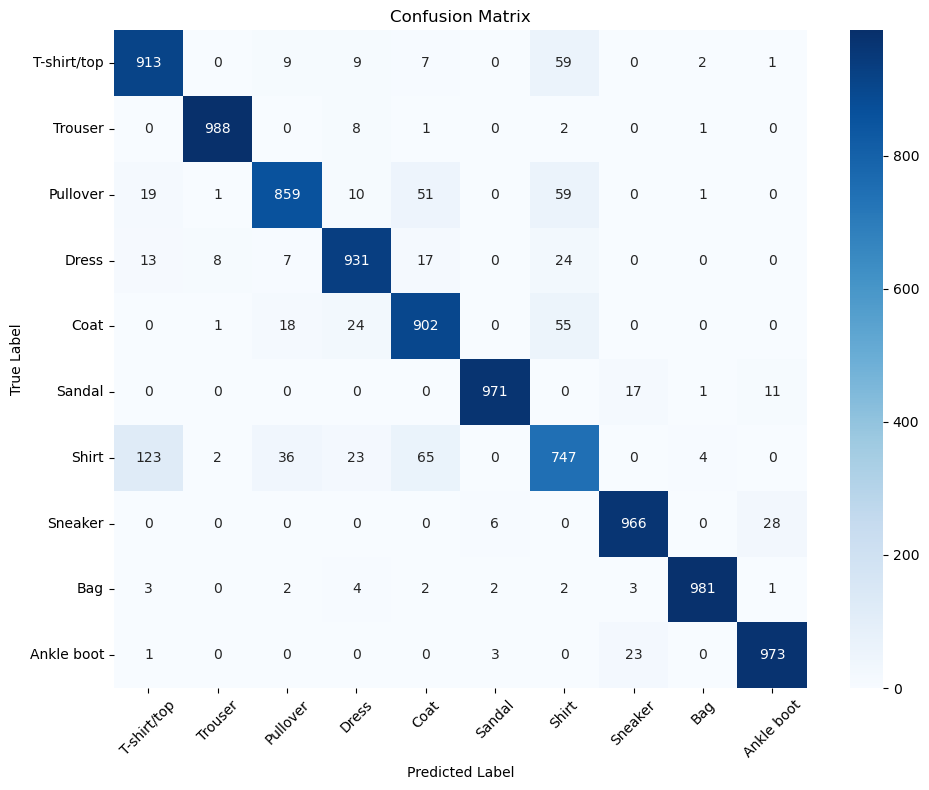


=== Precision, Recall, F1-Score ===
Micro Avg    - Precision: 0.9231, Recall: 0.9231, F1: 0.9231
Macro Avg    - Precision: 0.9233, Recall: 0.9231, F1: 0.9229
Weighted Avg - Precision: 0.9233, Recall: 0.9231, F1: 0.9229

=== Explanation of Aggregation Methods ===
1. Micro Averaging: Calculate total TP, FP, FN across all classes, then compute metrics
   Best for: Overall performance focus, ignoring class imbalance
2. Macro Averaging: Calculate metrics for each class separately, then take simple average
   Best for: All classes are equally important, care about per-class performance
3. Weighted Averaging: Calculate metrics for each class, then take weighted average by support
   Best for: Imbalanced datasets, giving more weight to classes with more samples

For Fashion-MNIST dataset, Macro Averaging is recommended because:
- Dataset is relatively balanced with similar samples per class
- We want good performance on all clothing categories equally
- Macro averaging better reflects average

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import seaborn as sns

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Data preprocessing and loading
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),  # Fashion-MNIST mean and std
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

# Load datasets
train_dataset = datasets.FashionMNIST(root='./data', train=True, 
                                     download=True, transform=transform_train)
test_dataset = datasets.FashionMNIST(root='./data', train=False, 
                                    download=True, transform=transform_test)

# Split training dataset into train and validation sets
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Fashion-MNIST class labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f'Training samples: {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')

# 1. Basic CNN Model - achieving ≥90% validation accuracy
class BasicCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(BasicCNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Pooling and regularization
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 3 * 3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        # Forward pass through convolutional layers
        x = self.pool(F.relu(self.conv1(x)))  # 28x28 -> 14x14
        x = self.pool(F.relu(self.conv2(x)))  # 14x14 -> 7x7
        x = self.pool(F.relu(self.conv3(x)))  # 7x7 -> 3x3
        
        # Flatten and pass through fully connected layers
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# 4. Two-Branch CNN Model using PyTorch's dynamic computation graph
class TwoBranchCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(TwoBranchCNN, self).__init__()
        
        # Branch 1: Traditional convolutional path
        self.branch1_conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.branch1_conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.branch1_pool = nn.MaxPool2d(2, 2)
        
        # Branch 2: Global average pooling path with different kernel size
        self.branch2_conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.branch2_conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.branch2_gap = nn.AdaptiveAvgPool2d(1)  # Global average pooling
        
        # Combined layers after concatenation
        self.fc1 = nn.Linear(64 * 7 * 7 + 64, 512)  # Branch1 + Branch2 features
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        # Branch 1: Traditional convolutional path with max pooling
        b1 = self.branch1_pool(F.relu(self.branch1_conv1(x)))  # 28x28 -> 14x14
        b1 = self.branch1_pool(F.relu(self.branch1_conv2(b1)))  # 14x14 -> 7x7
        b1 = b1.view(b1.size(0), -1)  # Flatten for concatenation
        
        # Branch 2: Global average pooling path
        b2 = F.relu(self.branch2_conv1(x))  # 28x28 (preserved size)
        b2 = F.relu(self.branch2_conv2(b2))  # 28x28 (preserved size)
        b2 = self.branch2_gap(b2)  # Global average pooling to 1x1
        b2 = b2.view(b2.size(0), -1)  # Flatten for concatenation
        
        # Combine outputs from both branches
        combined = torch.cat([b1, b2], dim=1)
        
        # Pass through fully connected layers
        x = F.relu(self.fc1(combined))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        
        return x

# Training function with validation
def train_model(model, train_loader, val_loader, num_epochs=15):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                val_loss += criterion(output, target).item()
                
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * correct / total
        
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)
        
        scheduler.step()
        
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {avg_train_loss:.4f}, '
              f'Val Loss: {avg_val_loss:.4f}, '
              f'Val Acc: {val_accuracy:.2f}%')
    
    return train_losses, val_losses, val_accuracies

# Test function to evaluate model performance
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output, 1)
            
            total += target.size(0)
            correct += (predicted == target).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')
    
    return all_predictions, all_targets, accuracy

# Create and plot confusion matrix (rows represent actual class)
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return cm

# Calculate precision and recall using different aggregation methods
def calculate_metrics(y_true, y_pred):
    # Micro averaging: Calculate metrics globally by counting total TP, FP, FN
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='micro')
    
    # Macro averaging: Calculate metrics for each class, then take unweighted mean
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro')
    
    # Weighted averaging: Calculate metrics for each class, then take weighted mean by support
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted')
    
    print("\n=== Precision, Recall, F1-Score ===")
    print(f"Micro Avg    - Precision: {precision_micro:.4f}, Recall: {recall_micro:.4f}, F1: {f1_micro:.4f}")
    print(f"Macro Avg    - Precision: {precision_macro:.4f}, Recall: {recall_macro:.4f}, F1: {f1_macro:.4f}")
    print(f"Weighted Avg - Precision: {precision_weighted:.4f}, Recall: {recall_weighted:.4f}, F1: {f1_weighted:.4f}")
    
    return {
        'micro': {'precision': precision_micro, 'recall': recall_micro, 'f1': f1_micro},
        'macro': {'precision': precision_macro, 'recall': recall_macro, 'f1': f1_macro},
        'weighted': {'precision': precision_weighted, 'recall': recall_weighted, 'f1': f1_weighted}
    }

# Train Basic CNN Model
print("=== Training Basic CNN Model ===")
basic_model = BasicCNN().to(device)
train_losses1, val_losses1, val_accs1 = train_model(basic_model, train_loader, val_loader)

# Test Basic CNN Model
print("\n=== Testing Basic CNN Model ===")
pred1, true1, acc1 = test_model(basic_model, test_loader)

# Train Two-Branch CNN Model
print("\n=== Training Two-Branch CNN Model ===")
branch_model = TwoBranchCNN().to(device)
train_losses2, val_losses2, val_accs2 = train_model(branch_model, train_loader, val_loader)

# Test Two-Branch CNN Model
print("\n=== Testing Two-Branch CNN Model ===")
pred2, true2, acc2 = test_model(branch_model, test_loader)

# Select best model for detailed analysis
if acc2 > acc1:
    best_model = branch_model
    best_pred = pred2
    best_true = true2
    print(f"\nBest model: Two-Branch CNN (Accuracy: {acc2:.2f}%)")
else:
    best_model = basic_model
    best_pred = pred1
    best_true = true1
    print(f"\nBest model: Basic CNN (Accuracy: {acc1:.2f}%)")

# Plot confusion matrix
print("\n=== Confusion Matrix ===")
cm = plot_confusion_matrix(best_true, best_pred, class_names)

# Calculate metrics using different aggregation methods
metrics = calculate_metrics(best_true, best_pred)

print("\n=== Explanation of Aggregation Methods ===")
print("1. Micro Averaging: Calculate total TP, FP, FN across all classes, then compute metrics")
print("   Best for: Overall performance focus, ignoring class imbalance")
print("2. Macro Averaging: Calculate metrics for each class separately, then take simple average")
print("   Best for: All classes are equally important, care about per-class performance")
print("3. Weighted Averaging: Calculate metrics for each class, then take weighted average by support")
print("   Best for: Imbalanced datasets, giving more weight to classes with more samples")
print("\nFor Fashion-MNIST dataset, Macro Averaging is recommended because:")
print("- Dataset is relatively balanced with similar samples per class")
print("- We want good performance on all clothing categories equally")
print("- Macro averaging better reflects average performance across all classes")

# Save model weights
torch.save(best_model.state_dict(), 'best_fashion_mnist_model.pth')
print("\nModel weights saved as 'best_fashion_mnist_model.pth'")